# Proje 4 — 3 Model Karşılaştırmalı Analiz

**Modeller:** ResNet50 (Klasik CNN) · EfficientNetB0 (Modern CNN) · ViT-Base/16 (Transformer)
**Veri seti:** Gameplay Images (10 sınıf, ~10K görsel, 70/15/15 split)
**Eğitim:** AdamW + CosineAnnealingLR, AMP, transfer learning (ImageNet pretrained)

Bu notebook, eğitilmiş 3 modelin sonuçlarını yan yana koyar; metrik tablosu, eğitim
eğrileri, confusion matrix, yanlış sınıflandırma örnekleri ve Grad-CAM karşılaştırması
içerir.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

from src.config import (
    CLASS_NAMES, FIGURES_DIR, LOGS_DIR, METRICS_CSV,
    MODELS_DIR, TEST_DIR,
)
from src.dataset import build_loaders
from src.models import create_model
from src.utils import get_device
from src.gradcam_utils import generate_gradcam, image_to_input_tensor, overlay_heatmap

device = get_device()
MODEL_NAMES = ["resnet50", "efficientnet_b0", "vit_base"]
DISPLAY = {"resnet50": "ResNet50", "efficientnet_b0": "EfficientNetB0", "vit_base": "ViT-Base/16"}
PARADIGM = {"resnet50": "Klasik CNN", "efficientnet_b0": "Modern CNN", "vit_base": "Transformer"}
COLORS = {"resnet50": "#2563eb", "efficientnet_b0": "#16a34a", "vit_base": "#dc2626"}

print(f"Device: {device}")
print(f"Models: {MODEL_NAMES}")


Device: cuda
Models: ['resnet50', 'efficientnet_b0', 'vit_base']


## 1. Metrik Tablosu

3 modelin test seti üzerindeki performansı + hesaplama maliyetleri.


In [2]:
df = pd.read_csv(METRICS_CSV)
df["model"] = pd.Categorical(df["model"], categories=MODEL_NAMES, ordered=True)
df = df.sort_values("model").reset_index(drop=True)
df["display"] = df["model"].map(DISPLAY)
df["paradigm"] = df["model"].map(PARADIGM)

cols = ["display", "paradigm", "accuracy", "macro_f1", "weighted_f1",
        "top3_accuracy", "params_m", "size_mb", "inference_ms_per_sample",
        "training_time_min"]
display_df = df[cols].rename(columns={
    "display": "Model", "paradigm": "Paradigma",
    "accuracy": "Acc", "macro_f1": "Macro-F1", "weighted_f1": "Weighted-F1",
    "top3_accuracy": "Top-3 Acc", "params_m": "Params (M)",
    "size_mb": "Boyut (MB)", "inference_ms_per_sample": "Inference (ms)",
    "training_time_min": "Train (dk)",
})
display_df.style.format({
    "Acc": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}",
    "Top-3 Acc": "{:.4f}", "Params (M)": "{:.1f}", "Boyut (MB)": "{:.1f}",
    "Inference (ms)": "{:.2f}", "Train (dk)": "{:.1f}",
}).hide(axis="index")


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14844\3185490781.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["model"] = pd.Categorical(df["model"], categories=MODEL_NAMES, ordered=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14844\

Model,Paradigma,Acc,Macro-F1,Weighted-F1,Top-3 Acc,Params (M),Boyut (MB),Inference (ms),Train (dk)
ResNet50,Klasik CNN,0.9913,0.9913,0.9913,0.9973,23.5,89.8,9.29,10.6
EfficientNetB0,Modern CNN,0.9907,0.9907,0.9907,0.9973,4.0,15.3,9.99,9.5
ViT-Base/16,Transformer,0.9907,0.9907,0.9907,0.9953,85.8,327.3,12.01,19.5


**Gözlemler:**
- 3 model de %99+ test accuracy'ye ulaştı — bu dataset için 3 mimari de yeterince güçlü.
- ResNet50 marjinal lider (%0.06 fark — istatistiksel gürültü içinde).
- EfficientNetB0 verimlilik kralı: 21× daha az parametre, 6× daha küçük dosya, neredeyse aynı doğruluk.
- ViT-Base/16 en yüksek val accuracy'yi (0.9960) elde etti ama test'te küçük bir düşüş gösterdi (0.5% gap → küçük overfit).


## 2. Eğitim Eğrileri (Overlay)

Loss ve accuracy'nin epoch boyunca değişimi — 3 model aynı eksenlerde.


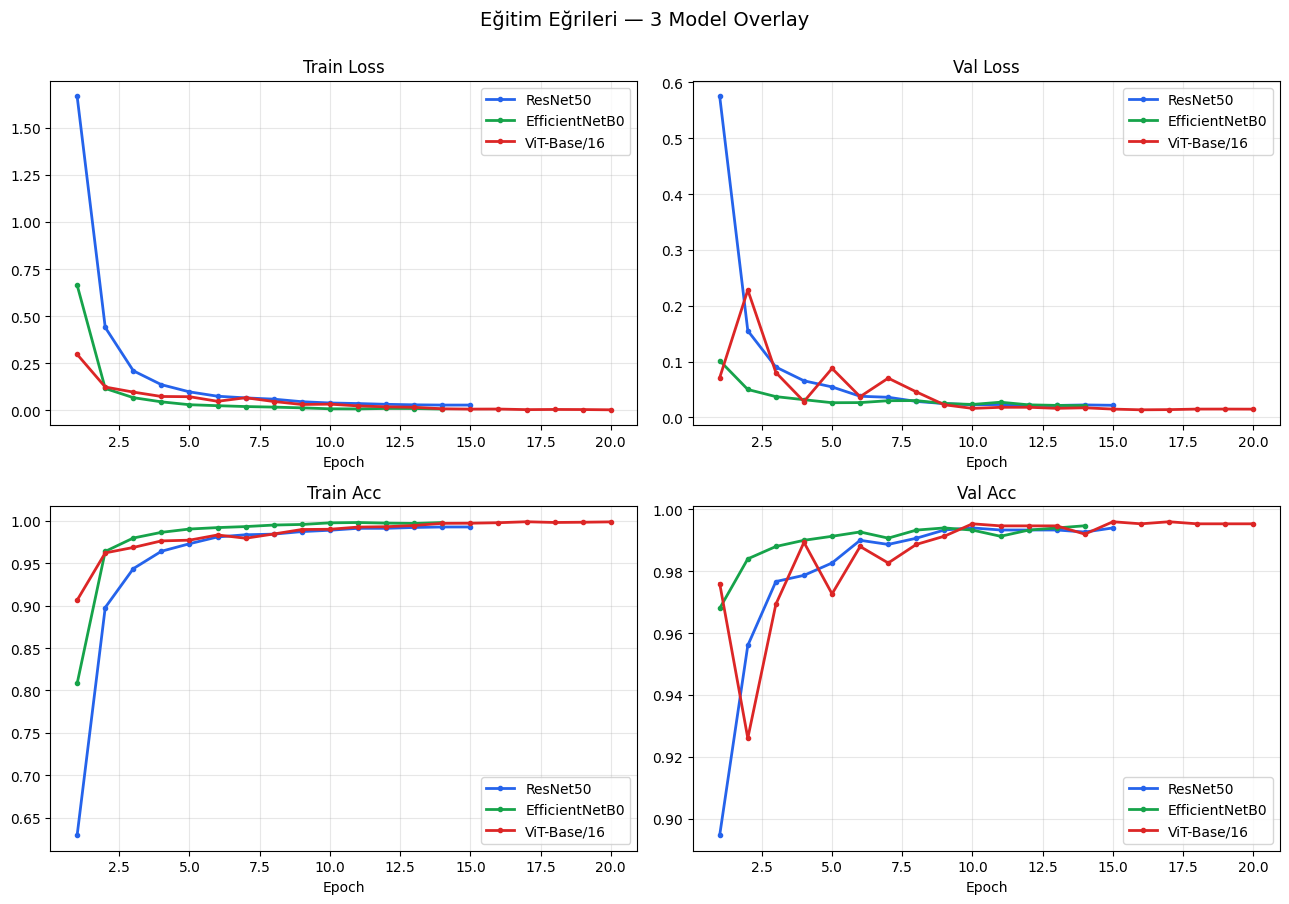

saved: C:\Users\ASUS\Desktop\dersler\derinogrenme_proje4\results\figures\comparison_curves_overlay.png


In [3]:
histories = {}
for name in MODEL_NAMES:
    hp = LOGS_DIR / f"{name}_history.csv"
    histories[name] = pd.read_csv(hp)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_specs = [
    ("train_loss", "Train Loss", axes[0, 0]),
    ("val_loss",   "Val Loss",   axes[0, 1]),
    ("train_acc",  "Train Acc",  axes[1, 0]),
    ("val_acc",    "Val Acc",    axes[1, 1]),
]
for col, title, ax in metric_specs:
    for name in MODEL_NAMES:
        h = histories[name]
        ax.plot(h["epoch"], h[col], label=DISPLAY[name],
                color=COLORS[name], linewidth=2, marker="o", markersize=3)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
plt.suptitle("Eğitim Eğrileri — 3 Model Overlay", fontsize=14, y=1.00)
plt.tight_layout()
out = FIGURES_DIR / "comparison_curves_overlay.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved: {out}")


**Gözlemler:**
- **ResNet50**: hızlı erken yakınsama, val loss düzenli düşer.
- **EfficientNetB0**: daha düzgün loss eğrisi, transfer learning ile çok hızlı yakınsama.
- **ViT-Base/16**: ilk epoch'larda **dalgalanma** (transformer fine-tuning karakteri), sonra düzelir; train accuracy en yükseğe çıkar (kapasite fazlası → overfitting eğilimi).
- 3 modelin de val accuracy'si 5-10. epoch'tan sonra plato yapıyor — daha uzun eğitim faydasız.


## 3. Confusion Matrix Karşılaştırması (Normalize)

Her modelin sınıf bazlı performansı. Normalize edilmiş — diagonal = recall.


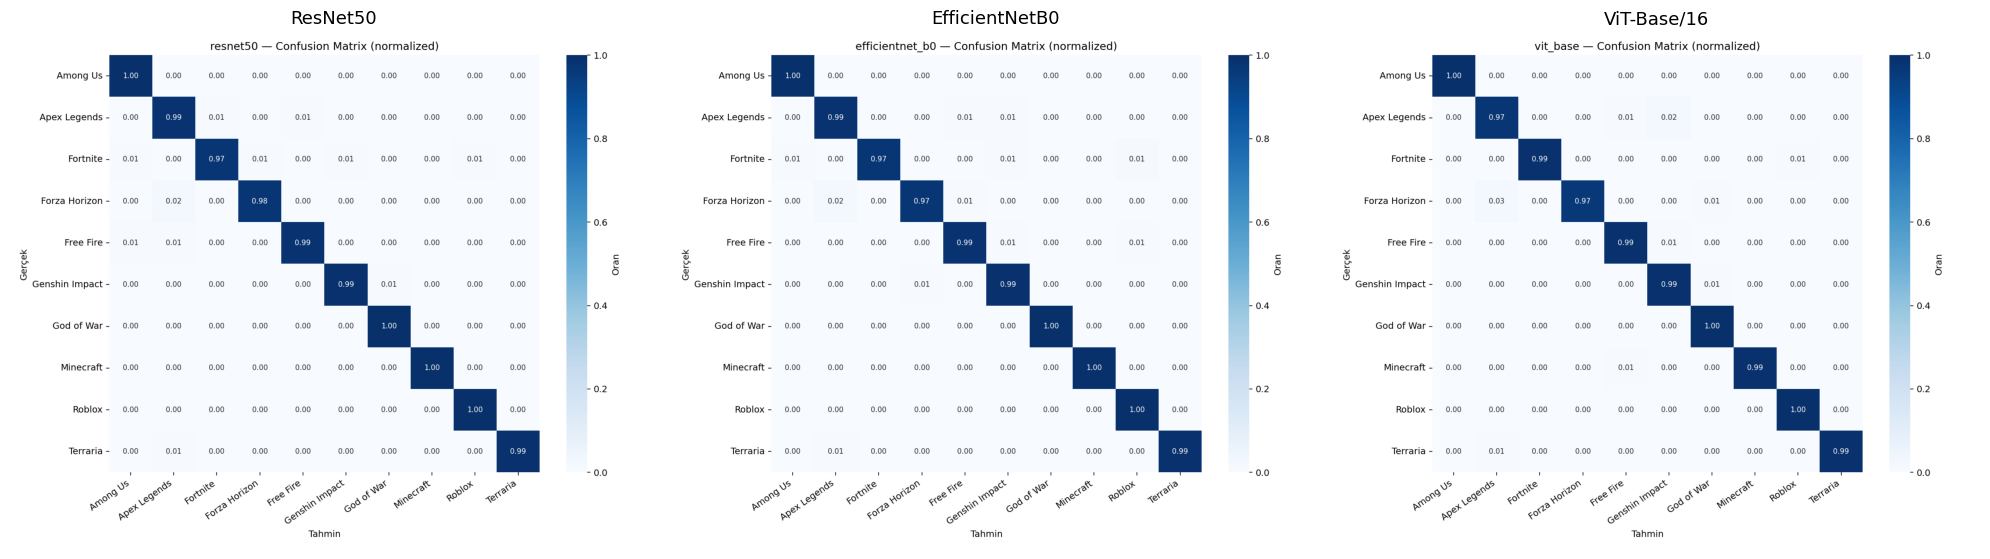

saved: C:\Users\ASUS\Desktop\dersler\derinogrenme_proje4\results\figures\comparison_confusion_grid.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, name in zip(axes, MODEL_NAMES):
    img = plt.imread(FIGURES_DIR / f"{name}_confusion_matrix_norm.png")
    ax.imshow(img)
    ax.set_title(DISPLAY[name], fontsize=13)
    ax.axis("off")
plt.tight_layout()
out = FIGURES_DIR / "comparison_confusion_grid.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved: {out}")


**Gözlemler:**
- 3 modelde de *Minecraft* mükemmel (1.0 recall) — en ayırt edici görsel stile sahip.
- *Apex Legends* en zor sınıf — diğer FPS'lerle (Free Fire, Fortnite) karıştırılma eğilimi.
- ViT'in *Forza Horizon* recall'u biraz daha düşük (0.97'den 0.967'ye) → küçük overfit göstergesi.


## 4. Yanlış Sınıflandırma Örnekleri

Her model için test setinde yanlış tahmin edilen ilk 3 görsel — gerçek vs tahmin etiketi.


C:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


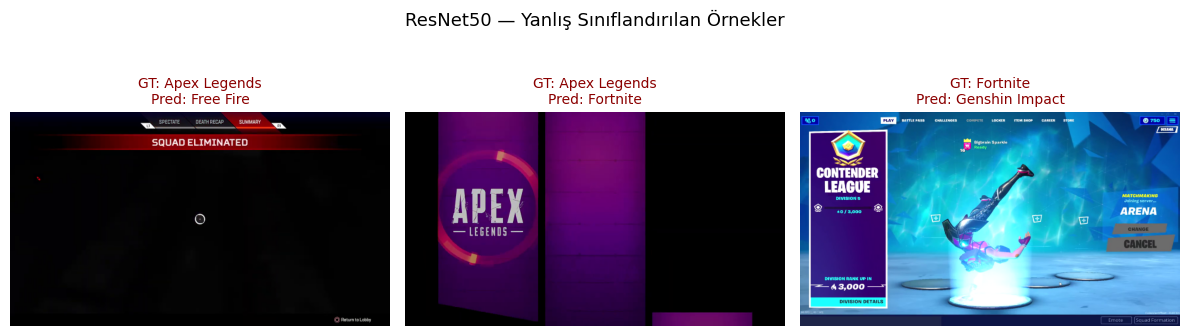

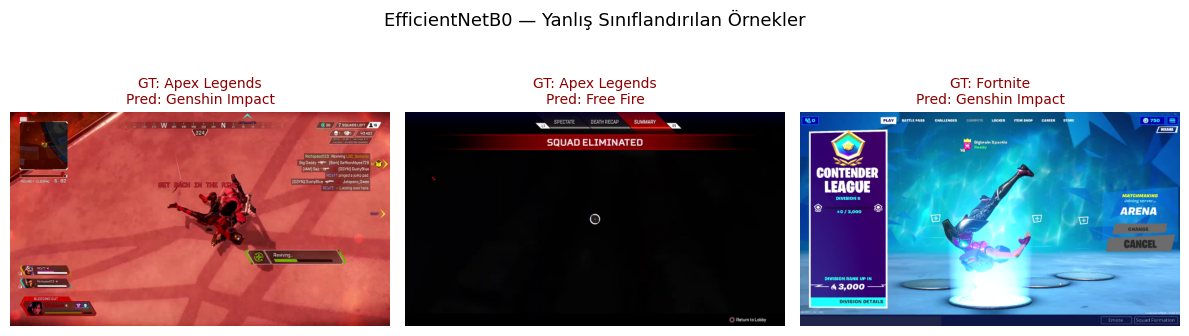

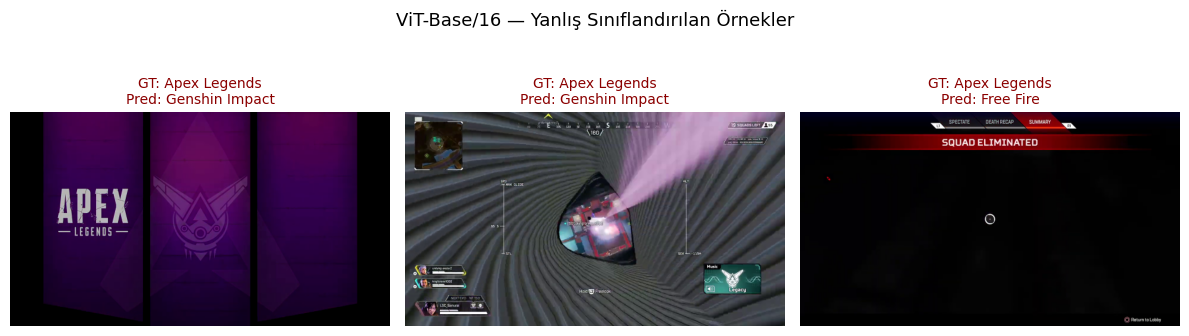

In [5]:
@torch.no_grad()
def get_misclassified(name: str, max_samples: int = 3):
    weights = MODELS_DIR / f"{name}.pth"
    model = create_model(name, pretrained=False).to(device)
    model.load_state_dict(torch.load(weights, map_location=device))
    model.eval()

    _, _, test_loader, _ = build_loaders(batch_size=32)
    samples = test_loader.dataset.samples  # [(path, label_idx), ...]

    wrong = []
    idx = 0
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds = model(x).argmax(dim=1).cpu().numpy()
        ys = y.numpy()
        for i in range(len(ys)):
            if preds[i] != ys[i]:
                path, _ = samples[idx + i]
                wrong.append({"path": path, "true": int(ys[i]), "pred": int(preds[i])})
                if len(wrong) >= max_samples:
                    return wrong, model
        idx += len(ys)
    return wrong, model


for name in MODEL_NAMES:
    wrong, _ = get_misclassified(name, max_samples=3)
    if not wrong:
        print(f"{DISPLAY[name]}: yanlış sınıflandırma yok (mükemmel!)")
        continue
    fig, axes = plt.subplots(1, len(wrong), figsize=(4 * len(wrong), 4))
    if len(wrong) == 1:
        axes = [axes]
    for ax, w in zip(axes, wrong):
        img = Image.open(w["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"GT: {CLASS_NAMES[w['true']]}\nPred: {CLASS_NAMES[w['pred']]}",
                     fontsize=10, color="darkred")
        ax.axis("off")
    plt.suptitle(f"{DISPLAY[name]} — Yanlış Sınıflandırılan Örnekler", fontsize=13)
    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()


## 5. Grad-CAM Karşılaştırması

Aynı görsele 3 modelin nereye baktığı. CNN'lerde GradCAM (sınıf-özel),
ViT'de EigenCAM (gradient-free, robust) kullanılır.


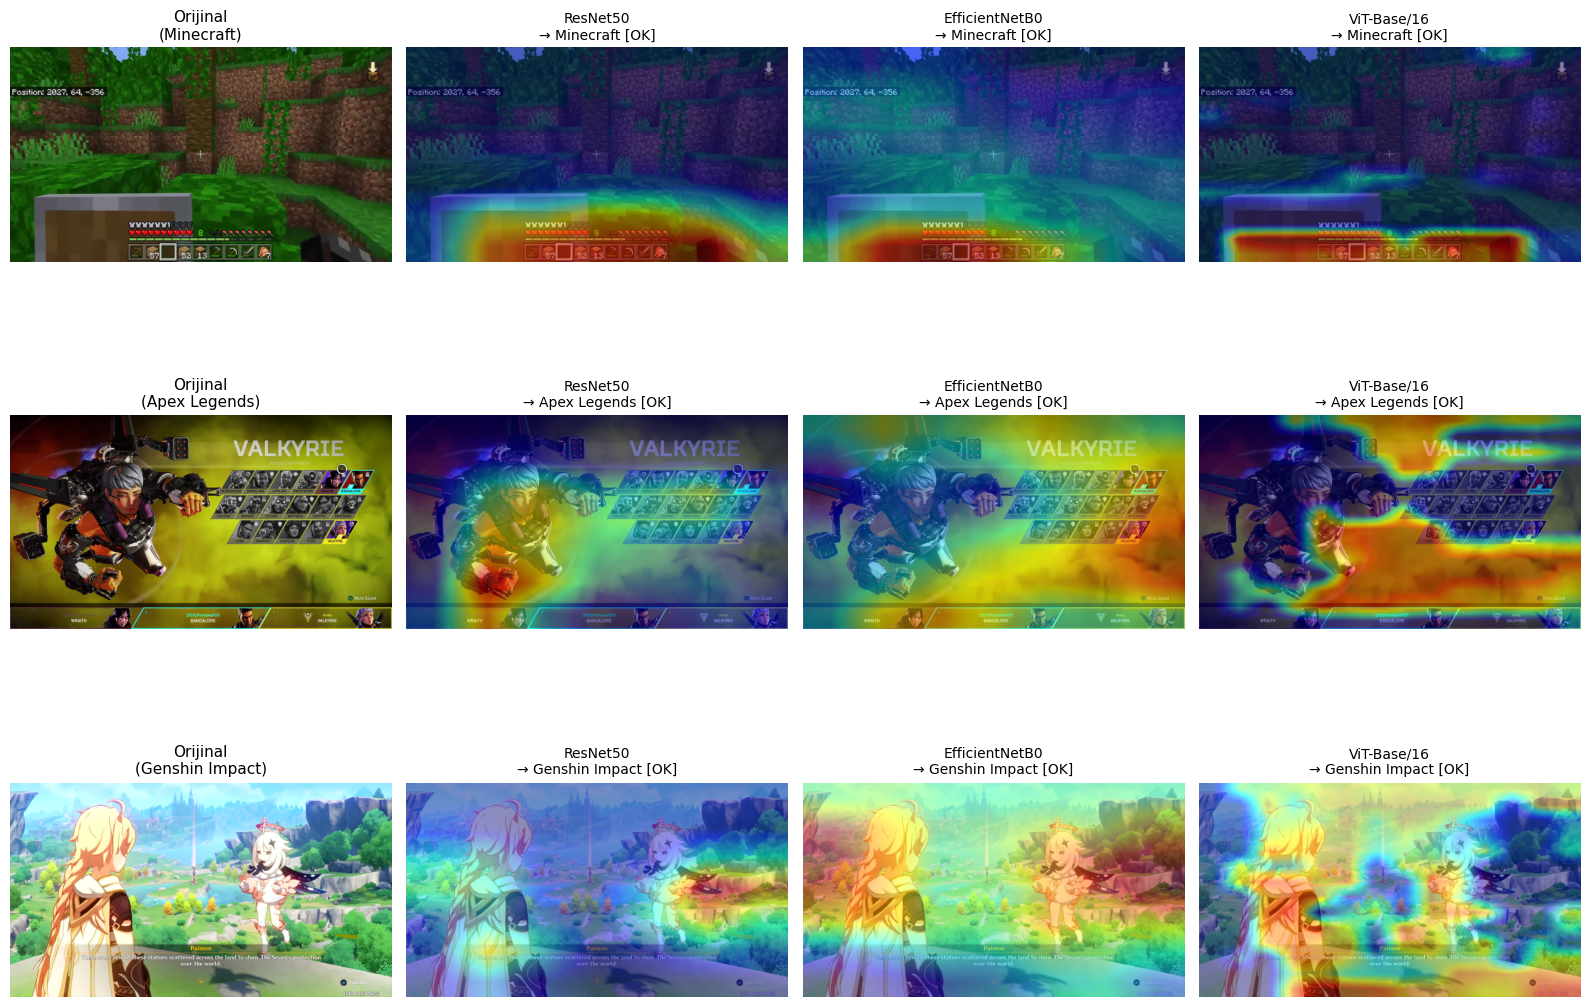

saved: C:\Users\ASUS\Desktop\dersler\derinogrenme_proje4\results\figures\comparison_gradcam.png


In [6]:
# 3 farklı sınıftan birer örnek seç
sample_paths = []
for cls in ["Minecraft", "Apex Legends", "Genshin Impact"]:
    cands = sorted((TEST_DIR / cls).glob("*"))
    if cands:
        sample_paths.append((cls, cands[0]))

# tüm modelleri yükle (3 görsel × 3 model = 9 heatmap)
loaded = {}
for name in MODEL_NAMES:
    m = create_model(name, pretrained=False).to(device)
    m.load_state_dict(torch.load(MODELS_DIR / f"{name}.pth", map_location=device))
    m.eval()
    loaded[name] = m

n_samples = len(sample_paths)
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
if n_samples == 1:
    axes = axes[None, :]

for row, (cls, path) in enumerate(sample_paths):
    pil = Image.open(path).convert("RGB")
    axes[row, 0].imshow(pil)
    axes[row, 0].set_title(f"Orijinal\n({cls})", fontsize=11)
    axes[row, 0].axis("off")
    for col, name in enumerate(MODEL_NAMES, start=1):
        tensor = image_to_input_tensor(pil, device)
        with torch.no_grad():
            pred_idx = int(loaded[name](tensor).argmax(dim=1).item())
        heatmap = generate_gradcam(loaded[name], name, tensor, target_class=pred_idx)
        overlay = overlay_heatmap(pil, heatmap, alpha=0.45)
        axes[row, col].imshow(overlay)
        pred_class = CLASS_NAMES[pred_idx]
        match = "OK" if pred_class == cls else "WRONG"
        axes[row, col].set_title(f"{DISPLAY[name]}\n→ {pred_class} [{match}]", fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout()
out = FIGURES_DIR / "comparison_gradcam.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved: {out}")

# bellek
del loaded
torch.cuda.empty_cache()


**Gözlemler:**
- CNN'ler (ResNet50, EfficientNetB0) lokalize bölgelere odaklanır — karakter modelleri, UI elementleri, oyun-spesifik dokular.
- ViT (EigenCAM) tipik olarak daha **dağınık** bir attention paterni gösterir — patch'lerin global ilişkisini kullanır, tek bir nesneye değil sahnenin geneline bakar.
- Bu fark, "CNN = lokal pattern detector / ViT = global context aggregator" sezgisiyle uyumlu.


## 6. Doğruluk vs Maliyet (Pareto)

Hangi model, hangi maliyetle ne kadar doğruluk sunuyor?


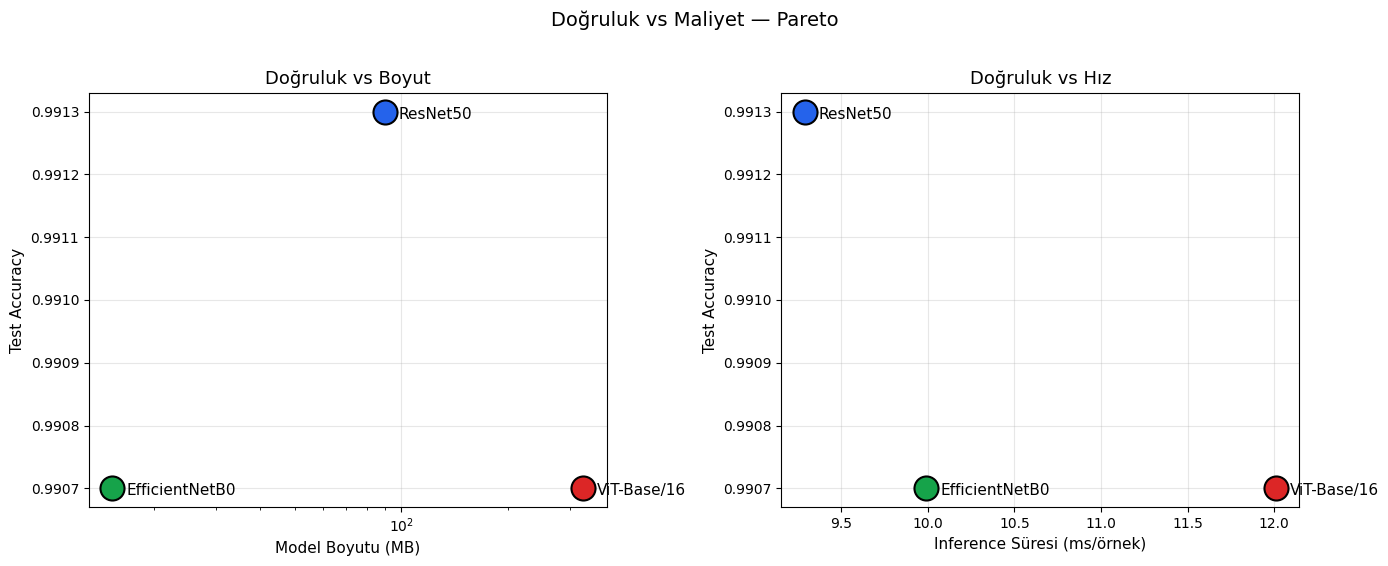

saved: C:\Users\ASUS\Desktop\dersler\derinogrenme_proje4\results\figures\comparison_pareto.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# panel 1: accuracy vs size
for _, row in df.iterrows():
    name = row["model"]
    axes[0].scatter(row["size_mb"], row["accuracy"],
                    s=300, color=COLORS[name], edgecolor="black", linewidth=1.5,
                    label=DISPLAY[name], zorder=3)
    axes[0].annotate(DISPLAY[name],
                     (row["size_mb"], row["accuracy"]),
                     xytext=(10, -5), textcoords="offset points", fontsize=11)
axes[0].set_xlabel("Model Boyutu (MB)", fontsize=11)
axes[0].set_ylabel("Test Accuracy", fontsize=11)
axes[0].set_title("Doğruluk vs Boyut", fontsize=13)
axes[0].grid(alpha=0.3)
axes[0].set_xscale("log")

# panel 2: accuracy vs inference time
for _, row in df.iterrows():
    name = row["model"]
    axes[1].scatter(row["inference_ms_per_sample"], row["accuracy"],
                    s=300, color=COLORS[name], edgecolor="black", linewidth=1.5,
                    label=DISPLAY[name], zorder=3)
    axes[1].annotate(DISPLAY[name],
                     (row["inference_ms_per_sample"], row["accuracy"]),
                     xytext=(10, -5), textcoords="offset points", fontsize=11)
axes[1].set_xlabel("Inference Süresi (ms/örnek)", fontsize=11)
axes[1].set_ylabel("Test Accuracy", fontsize=11)
axes[1].set_title("Doğruluk vs Hız", fontsize=13)
axes[1].grid(alpha=0.3)

plt.suptitle("Doğruluk vs Maliyet — Pareto", fontsize=14, y=1.02)
plt.tight_layout()
out = FIGURES_DIR / "comparison_pareto.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved: {out}")


**Gözlemler:**
- **EfficientNetB0** Pareto-optimal: en küçük + en hızlı + neredeyse en yüksek accuracy → **deployment için ideal**.
- ResNet50 dengeli (orta boy, orta hız, en yüksek accuracy).
- ViT-Base/16: en pahalı (4× boyut, %30 daha yavaş), accuracy avantajı yok → bu dataset için aşırı kapasite.


## Sonuç

| Boyut | Kazanan | Neden |
|---|---|---|
| **Test accuracy** | ResNet50 (0.9913) | Marjinal — istatistiksel gürültü içinde |
| **Verimlilik** | EfficientNetB0 (15 MB, 9.5 dk eğitim) | Production deployment için kanıtlanmış tercih |
| **Val accuracy** | ViT-Base/16 (0.9960) | En yüksek kapasite ama test'te küçük overfit |

**Tezimiz**: Bu dataset (10 oyun × 1000 görsel, görsel olarak çok ayırt edici) için
3 mimari de eşdeğer kalitede sınıflandırma yapar. Mimari seçimi, *doğruluk* yerine
*verimlilik kısıtları* (deployment hedefi, cihaz sınırları, eğitim bütçesi) tarafından
yönlendirilmelidir.

Web demo, bu üç modeli aynı arayüzde yan yana çalıştırarak bu argümanı interaktif
biçimde gösterir — kullanıcı kendi yüklediği görselle 3 modelin yargılarını ve
attention bölgelerini doğrudan kıyaslayabilir.
